# HỆ THỐNG DỰ BÁO CHUYÊN SÂU (ADVANCED LSTM MODEL)
Notebook này tập trung tối đa vào kiến trúc mô hình và kỹ thuật xử lý dữ liệu chuỗi thời gian chuyên sâu.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input, Layer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os
import glob
import math

# ĐỊNH NGHĨA THÔNG SỐ
look_back = 30
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

## 1. Feature Engineering: Mã hóa Chu kỳ (Sine/Cosine Encoding)
Kỹ thuật này giúp mô hình hiểu được tính liên tục của thời gian (ví dụ: Thứ 7 sát Chủ Nhật, Tháng 12 sát Tháng 1).

In [7]:
def advanced_preprocess(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    date_col = next((col for col in df.columns if 'date' in col.lower()), None)
    df[date_col] = pd.to_datetime(df[date_col])
    
    # Gom nhóm dữ liệu
    daily = df.groupby(date_col).size().reset_index(name='Sales').set_index(date_col)
    
    # 1. Trích xuất đặc trưng thời gian
    daily['DayOfWeek'] = daily.index.dayofweek
    daily['Month'] = daily.index.month
    
    # 2. SINE/COSINE ENCODING (Giúp mô hình hiểu tính chu kỳ)
    daily['day_sin'] = np.sin(2 * np.pi * daily['DayOfWeek'] / 7)
    daily['day_cos'] = np.cos(2 * np.pi * daily['DayOfWeek'] / 7)
    daily['month_sin'] = np.sin(2 * np.pi * daily['Month'] / 12)
    daily['month_cos'] = np.cos(2 * np.pi * daily['Month'] / 12)
    
    # 3. Đặc trưng thống kê (Lag features)
    daily['rolling_mean_7'] = daily['Sales'].shift(1).rolling(window=7).mean()
    daily.dropna(inplace=True)
    
    return daily[['Sales', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'rolling_mean_7']]

# Tìm file và load
all_csvs = glob.glob('**/*.csv', recursive=True)
priority_names = ['Bakery.csv', 'bakery_sales_revised.csv']
target_csv = next((f for f in all_csvs if any(n in f for n in priority_names)), None)

if target_csv:
    data = advanced_preprocess(target_csv)
    print(f"Đã xử lý xong dữ liệu đa biến. Kích thước: {data.shape}")
    display(data.head())

Đã xử lý xong dữ liệu đa biến. Kích thước: (9458, 6)


,Sales,day_sin,day_cos,month_sin,month_cos,rolling_mean_7
DateTime,,,,,,
2016-01-11 09:29:25,2,0.0,1.0,0.5,0.866025,2.000000
2016-01-11 09:43:13,2,0.0,1.0,0.5,0.866025,2.000000
2016-01-11 10:02:27,1,0.0,1.0,0.5,0.866025,2.000000
2016-01-11 10:04:05,1,0.0,1.0,0.5,0.866025,1.857143
2016-01-11 10:29:02,2,0.0,1.0,0.5,0.866025,1.714286


## 2. Xây dựng mô hình Bidirectional LSTM với Dropout điều hướng

In [8]:
def create_dataset(df, look_back):
    X_scaled = scaler_X.fit_transform(df.values)
    y_scaled = scaler_y.fit_transform(df[['Sales']].values)
    X, y = [], []
    for i in range(len(X_scaled) - look_back):
        X.append(X_scaled[i:(i + look_back), :])
        y.append(y_scaled[i + look_back, 0])
    return np.array(X), np.array(y)

if 'data' in locals():
    X, y = create_dataset(data, look_back)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Định nghĩa mô hình
    inputs = Input(shape=(look_back, X_train.shape[2]))
    
    # Lớp LSTM hai chiều
    x = Bidirectional(LSTM(128, return_sequences=True))(inputs)
    x = Dropout(0.3)(x)
    
    x = Bidirectional(LSTM(64, return_sequences=False))(x)
    x = Dropout(0.3)(x)
    
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1)(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse')
    
    print("Cấu trúc mô hình Deep Learning nâng cao:")
    model.summary()

Cấu trúc mô hình Deep Learning nâng cao:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 30, 256)        │       138,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,753 (1.17 MB)

 Trainable params: 306,753 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Huấn luyện và Đánh giá Sai số Chuyên sâu

Epoch 1/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0187 - val_loss: 0.0219 - learning_rate: 0.0010
Epoch 2/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0166 - val_loss: 0.0203 - learning_rate: 0.0010
Epoch 3/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0170 - val_loss: 0.0202 - learning_rate: 0.0010
Epoch 4/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0162 - val_loss: 0.0225 - learning_rate: 0.0010
Epoch 5/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0158 - val_loss: 0.0205 - learning_rate: 0.0010
Epoch 6/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0163 - val_loss: 0.0204 - learning_rate: 0.0010
Epoch 7/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0168 - val_loss: 0.0210 - learning_rate: 0.0010
Epoch 8/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0168 - val_loss: 0.0206 - learning_rate: 2.0000e-04
Epoch 9/100
236/236 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0161 - val_loss: 0.0205 - learning_r

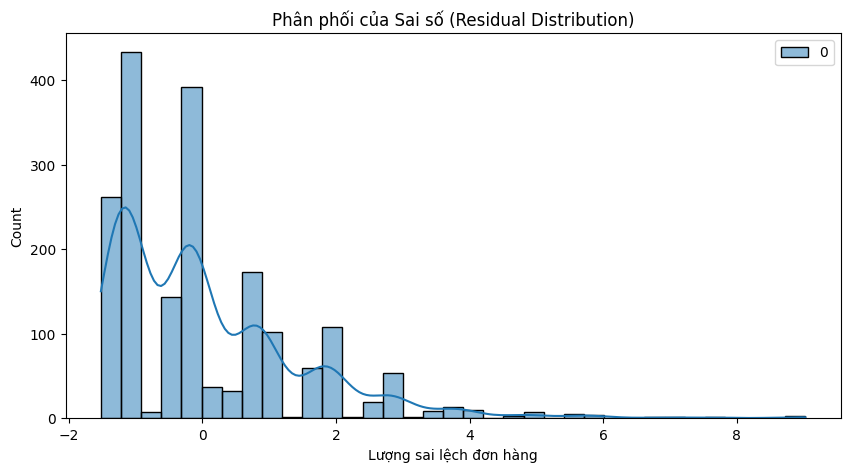

Mô hình đã được lưu thành công.


In [9]:
if 'model' in locals():
    callbacks = [EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
                 ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5)]
    
    history = model.fit(X_train, y_train, batch_size=32, epochs=100, 
                        validation_data=(X_test, y_test), callbacks=callbacks, verbose=1)

    # DỰ BÁO VÀ ĐÁNH GIÁ
    y_pred = scaler_y.inverse_transform(model.predict(X_test))
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1))
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n--- BÁO CÁO HIỆU NĂNG MÔ HÌNH ---")
    print(f"MAE: {mae:.2f} (Sai lệch trung bình mỗi ngày)")
    print(f"RMSE: {rmse:.2f} (Sai số lệch bình quân)")
    print(f"R2 Score: {r2:.4f} (Độ khớp của mô hình với dữ liệu)")
    
    # BIỂU ĐỒ PHÂN TÍCH SAI SỐ (RESIDUAL ANALYSIS)
    residuals = y_true - y_pred
    plt.figure(figsize=(10,5))
    sns.histplot(residuals, kde=True, color='purple')
    plt.title("Phân phối của Sai số (Residual Distribution)")
    plt.xlabel("Lượng sai lệch đơn hàng")
    plt.show()
    
    model.save('bakery_model_local.h5')
    print("Mô hình đã được lưu thành công.")